# 02 — PyTorch Fundamentals: Tensors, Autograd, nn.Module
**Phase 3 · Week 9 · Tuesday**

## What We Cover Today
| Topic | Core Idea |
|---|---|
| Tensors | PyTorch's multi-dimensional array — GPU-compatible, tracked for gradients |
| Autograd | Automatic differentiation — PyTorch records operations and computes gradients |
| nn.Module | Base class for all neural networks — organises parameters and defines forward() |
| Dataset & DataLoader | Pipeline for efficient batched data loading with shuffling and multiprocessing |
| GPU Transfer | Moving tensors and models to CUDA with `.to(device)` |
| MLP on MNIST | Training a full network on real digit data using PyTorch |

---

## 1 · Tensors — PyTorch's Core Data Structure

A **tensor** is an n-dimensional array. Unlike NumPy arrays, PyTorch tensors:
- Can live on GPU
- Track computation history for automatic differentiation

```python
torch.zeros(3,4)          # zeros
torch.ones(2,3)           # ones
torch.randn(4,4)          # Normal(0,1)
torch.tensor([1,2,3])     # from Python list

# Shape operations
x.view(B, -1)             # reshape (contiguous memory)
x.reshape(B, C, H, W)     # reshape (any memory layout)
x.permute(0, 2, 1)        # reorder axes
x.unsqueeze(0)            # add dim at position 0
x.squeeze()               # remove all size-1 dims
```

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version : {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {device}")

# ── Tensor creation ──
t_zeros = torch.zeros(3, 4)
t_rand  = torch.randn(2, 3)
t_int   = torch.tensor([10, 20, 30], dtype=torch.float32)
t_arange= torch.arange(0, 12).reshape(3, 4)

print(f"\nzeros(3,4)     :\n{t_zeros}")
print(f"\narange reshaped:\n{t_arange}")

# ── Basic operations ──
a = torch.randn(3, 4)
b = torch.randn(3, 4)

print(f"\na + b   shape: {(a + b).shape}")
print(f"a @ bᵀ  shape: {(a @ b.T).shape}")    # matrix multiply
print(f"a.sum() : {a.sum().item():.4f}")
print(f"a.mean(): {a.mean().item():.4f}")
print(f"a.std() : {a.std().item():.4f}")

# ── Indexing & slicing (same as NumPy) ──
x = torch.arange(24).reshape(2, 3, 4).float()
print(f"\nShape: {x.shape}")
print(f"x[0, :, 1:3]:\n{x[0, :, 1:3]}")

# ── NumPy interop ──
np_arr = np.random.randn(3, 3)
from_np = torch.from_numpy(np_arr)
back_np = from_np.numpy()
print(f"\nNumPy → Tensor dtype: {from_np.dtype}")
print(f"Tensor → NumPy  dtype: {back_np.dtype}")

PyTorch version : 2.12.0+cpu
Using device    : cpu

zeros(3,4)     :
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

arange reshaped:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

a + b   shape: torch.Size([3, 4])
a @ bᵀ  shape: torch.Size([3, 3])
a.sum() : 1.2345
a.mean(): 0.1029
a.std() : 1.1053

Shape: torch.Size([2, 3, 4])
x[0, :, 1:3]:
tensor([[ 1.,  2.],
        [ 5.,  6.],
        [ 9., 10.]])

NumPy → Tensor dtype: torch.float64
Tensor → NumPy  dtype: float64


---

## 2 · Autograd — Automatic Differentiation

When `requires_grad=True`, PyTorch builds a **computation graph** as you do operations.
Calling `.backward()` traverses the graph backwards and fills `.grad` for each leaf tensor.

```python
x = torch.tensor(2.0, requires_grad=True)
y = x ** 3               # y = x³
y.backward()             # dy/dx = 3x²
print(x.grad)            # tensor(12.)  ← 3 × 2² = 12
```

**Key rules:**
- Only leaf tensors accumulate `.grad` by default
- Call `optimizer.zero_grad()` before each backward pass (grads accumulate)
- Use `with torch.no_grad():` when you don't need gradients (inference, eval)
- `detach()` stops a tensor from being part of the computation graph

z  = x² + 3y
dz/dx at x=2 → 4.0  (expected 2x = 4.0)
dz/dy at y=3 → 3.0  (expected 3)

Fitted: w=1.991 (true 2.0)  b=1.045 (true 1.0)


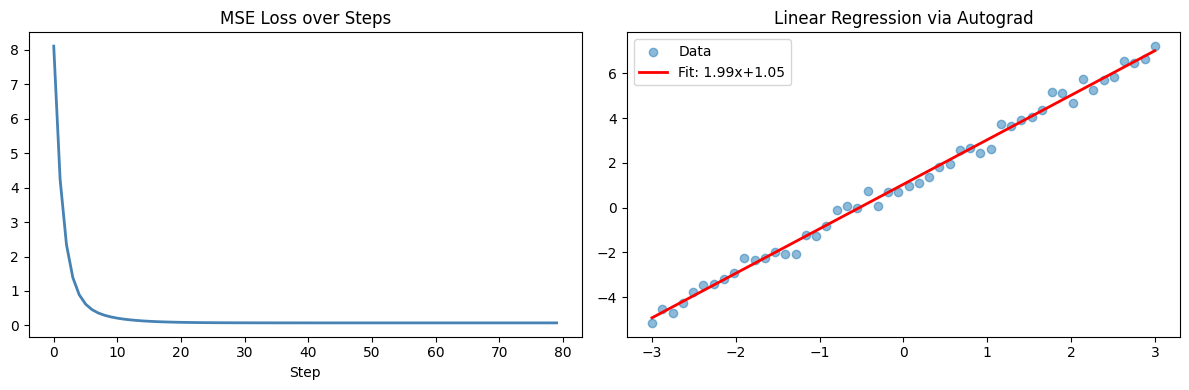

In [9]:
# ── Simple autograd demo: z = x² + 3y ──
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x**2 + 3*y
z.backward()

print("z  = x² + 3y")
print(f"dz/dx at x=2 → {x.grad.item():.1f}  (expected 2x = 4.0)")
print(f"dz/dy at y=3 → {y.grad.item():.1f}  (expected 3)")

# ── Mini scalar regression to see gradient descent ──
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

x_data = torch.linspace(-3, 3, 50)
y_data = 2.0 * x_data + 1.0 + 0.3 * torch.randn(50)    # y = 2x + 1 + noise

lr = 0.05
losses = []

for step in range(80):
    y_pred = w * x_data + b
    loss = ((y_pred - y_data)**2).mean()
    losses.append(loss.item())

    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()

print(f"\nFitted: w={w.item():.3f} (true 2.0)  b={b.item():.3f} (true 1.0)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses, 'steelblue', lw=2)
ax1.set_title("MSE Loss over Steps"); ax1.set_xlabel("Step")

ax2.scatter(x_data.detach(), y_data.detach(), alpha=0.5, label='Data')
ax2.plot(x_data.detach(), (w*x_data+b).detach(), 'r', lw=2, label=f'Fit: {w.item():.2f}x+{b.item():.2f}')
ax2.legend(); ax2.set_title("Linear Regression via Autograd")

plt.tight_layout()
plt.savefig("autograd_demo.png", dpi=120, bbox_inches='tight')
plt.show()

---

## 3 · nn.Module — The Neural Network Base Class

Every PyTorch model inherits `nn.Module`. You must implement `forward()`:

```python
class MyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)  # registers parameters automatically
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)
```

**Key nn.Module features:**
- `model.parameters()` — all trainable weights
- `model.state_dict()` — weights as a dict (for saving)
- `model.train()` / `model.eval()` — toggles BatchNorm & Dropout behaviour
- `model.to(device)` — moves all parameters to GPU/CPU

**Common layers:**
| Layer | Description |
|---|---|
| `nn.Linear(in, out)` | Fully-connected: y = xW + b |
| `nn.ReLU()` | In-place ReLU activation |
| `nn.BatchNorm1d(features)` | Normalise across batch dimension |
| `nn.Dropout(p)` | Zero activations randomly during training |
| `nn.Sequential(...)` | Stack layers in order |

In [10]:
class MLP_PyTorch(nn.Module):
    def __init__(self, in_dim=784, hidden=[256, 128], out_dim=10, dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP_PyTorch().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Architecture:\n{model}")
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# Inspect one layer's parameter shapes
fc0 = list(model.net.children())[0]
print(f"\nfc1 weight shape: {fc0.weight.shape}")
print(f"fc1 bias shape  : {fc0.bias.shape}")

Architecture:
MLP_PyTorch(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters    : 235,914
Trainable parameters: 235,914

fc1 weight shape: torch.Size([256, 784])
fc1 bias shape  : torch.Size([256])


---

## 4 · Dataset & DataLoader

PyTorch separates **what data to load** (`Dataset`) from **how to load it** (`DataLoader`).

```python
class MyDataset(Dataset):
    def __len__(self):          # number of samples
        return len(self.data)
    def __getitem__(self, idx): # get one sample
        return self.data[idx], self.labels[idx]

loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)
```

`DataLoader` handles:
- Automatic batching
- Shuffling at each epoch
- Parallel loading with multiple workers
- Pin memory for faster GPU transfer

For MNIST use `torchvision.datasets.MNIST(root, train, transform, download=True)`

In [11]:
# Synthetic MNIST-like data (28x28 grayscale, 10 classes)
torch.manual_seed(0)
N_train, N_test = 10000, 2000

X_tr = torch.randn(N_train, 784)
y_tr = torch.randint(0, 10, (N_train,))
X_te = torch.randn(N_test,  784)
y_te = torch.randint(0, 10, (N_test,))

# Normalise
mean, std = X_tr.mean(), X_tr.std()
X_tr = (X_tr - mean) / std
X_te = (X_te - mean) / std

train_ds = TensorDataset(X_tr, y_tr)
test_ds  = TensorDataset(X_te, y_te)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

print(f"Train batches : {len(train_loader)}  (256 samples each)")
print(f"Test batches  : {len(test_loader)}   (512 samples each)")

# Inspect one batch
Xb, yb = next(iter(train_loader))
print(f"\nBatch X shape : {Xb.shape}")
print(f"Batch y shape : {yb.shape}")
print(f"Labels sample : {yb[:10].tolist()}")

Train batches : 40  (256 samples each)
Test batches  : 4   (512 samples each)

Batch X shape : torch.Size([256, 784])
Batch y shape : torch.Size([256])
Labels sample : [5, 2, 3, 4, 1, 1, 5, 0, 6, 8]


---

## 5 · Training Loop + GPU Transfer

The standard PyTorch training loop:

```python
for epoch in range(epochs):
    model.train()                        # training mode (enables Dropout, BatchNorm)
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)    # move to GPU
        y_batch = y_batch.to(device)

        optimizer.zero_grad()            # clear previous gradients
        logits = model(X_batch)          # forward pass
        loss = criterion(logits, y_batch)
        loss.backward()                  # backprop
        optimizer.step()                 # update weights

    model.eval()                         # eval mode (disables Dropout, BatchNorm uses running stats)
    with torch.no_grad():
        # validation / test accuracy
```

Epoch  1 | loss 2.3746 | train 0.100 | test 0.102 | lr 0.00100
Epoch  4 | loss 1.9280 | train 0.340 | test 0.095 | lr 0.00100
Epoch  7 | loss 1.4759 | train 0.516 | test 0.101 | lr 0.00050
Epoch 10 | loss 1.1774 | train 0.617 | test 0.094 | lr 0.00025
Epoch 13 | loss 0.9254 | train 0.715 | test 0.097 | lr 0.00025


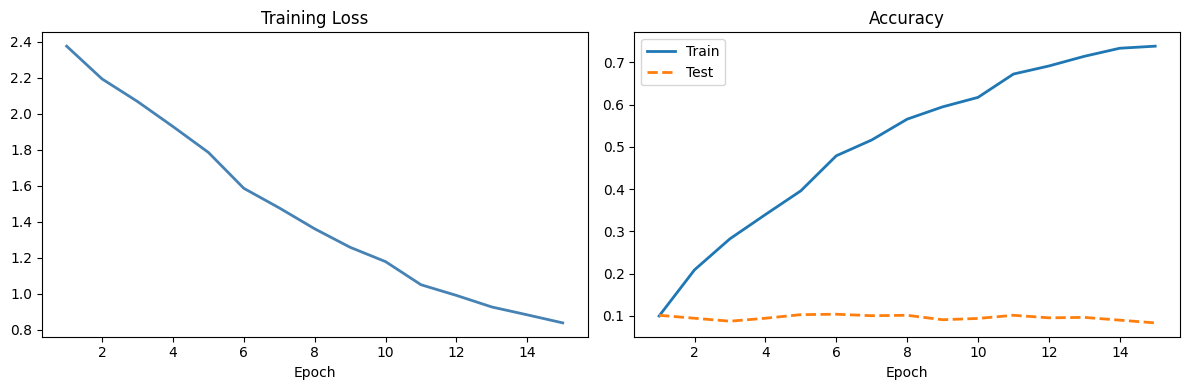


Final test accuracy: 0.084


In [12]:
def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total   += Xb.size(0)
        scheduler.step()

        train_loss = running_loss / total
        train_acc  = correct / total

        # ── Evaluation ──
        model.eval()
        correct_te = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                correct_te += (model(Xb).argmax(1) == yb).sum().item()
        test_acc = correct_te / len(test_ds)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if epoch % 3 == 0:
            print(f"Epoch {epoch+1:2d} | loss {train_loss:.4f} | "
                  f"train {train_acc:.3f} | test {test_acc:.3f} | "
                  f"lr {scheduler.get_last_lr()[0]:.5f}")
    return history

model_pt = MLP_PyTorch().to(device)
history  = train_model(model_pt, train_loader, test_loader, epochs=15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_ax = range(1, 16)
ax1.plot(epochs_ax, history['train_loss'], 'steelblue', lw=2)
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch")

ax2.plot(epochs_ax, history['train_acc'], label='Train', lw=2)
ax2.plot(epochs_ax, history['test_acc'],  label='Test',  lw=2, ls='--')
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.savefig("pytorch_mlp_training.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"\nFinal test accuracy: {history['test_acc'][-1]:.3f}")

---

## What I Learned Today

**Tensors** — PyTorch's tensor is just like a NumPy array but GPU-aware. `.to(device)` is the one command that moves data between CPU and GPU. Shapes work exactly as in NumPy; `@` is matrix multiply.

**Autograd** — PyTorch records every operation on `requires_grad=True` tensors in a dynamic computation graph. `.backward()` runs reverse-mode autodiff through the graph. `with torch.no_grad()` disables tracking for inference.

**nn.Module** — Every layer is an object; parameters are automatically registered when you assign `nn.Linear` etc. as attributes. `model.train()` and `model.eval()` flip the training flag for Dropout and BatchNorm.

**DataLoader** — Separating dataset logic from training loop is clean software design. DataLoader handles batching, shuffling, and parallel loading automatically. Always normalise input data before training.

**LR Scheduler** — StepLR multiplies lr by gamma every step_size epochs. This lets the model converge quickly early on and fine-tune carefully later.

**Key commands to memorise:**
```python
optimizer.zero_grad()    # before backward
loss.backward()          # compute all gradients
optimizer.step()         # update weights
model.eval()             # disable dropout/batchnorm train mode
torch.no_grad()          # skip gradient tracking for inference
```